In [1]:
!pip install git+https://github.com/rwightman/pytorch-image-models.git

  Cloning https://github.com/rwightman/pytorch-image-models.git to /tmp/pip-req-build-xsa3sjfp
  Running command git clone --filter=blob:none --quiet https://github.com/rwightman/pytorch-image-models.git /tmp/pip-req-build-xsa3sjfp
  Resolved https://github.com/rwightman/pytorch-image-models.git to commit a6da4da1740cd57eaf864803f9dd65683cbcf6d7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for timm: filename=timm-1.0.29.dev0-py3-none-any.whl size=2603260 sha256=c8eb49638d31efc36639849055f24597a3a7dffa881bb178364f79fa72e6e335
  Stored in directory: /tmp/pip-ephem-wheel-cache-a_h6273l/wheels/62/3c/74/390e961b002559b53451e6fb321c0865417204fd65d3becc9d
Successfully built timm
  Attempting uninstall: timm
    Found existing installation: timm 1.0.28
    Uninstalling timm-1.0.28:
      Successfully uninstalled timm-1.0.28


In [2]:
# Core Python
import os
import math
import time
from datetime import timedelta
import warnings
warnings.filterwarnings("ignore")
import h5py

# Scientific and Data Libraries
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix,
    classification_report
)

# PyTorch and Deep Learning
import torch
from torch.utils.data import Dataset, DataLoader, Subset, random_split

# Vision Libraries
from torchvision import transforms
import timm  # For pretrained transformer models

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress Bar
from tqdm.auto import tqdm

In [5]:
!pip install -q kagglehub

In [6]:
import os
import kagglehub

path = kagglehub.dataset_download("ashkhagan/figshare-brain-tumor-dataset")

print("Downloaded to:", path)

Using Colab cache for faster access to the 'figshare-brain-tumor-dataset' dataset.
Downloaded to: /kaggle/input/figshare-brain-tumor-dataset


In [14]:
import os
import h5py

mat_files = []

for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith(".mat"):
            full = os.path.join(root, f)

            try:
                with h5py.File(full, "r") as hf:
                    if "cjdata" in hf:
                        mat_files.append(full)
            except:
                pass

print("MRI files found:", len(mat_files))

if len(mat_files):
    print(mat_files[:5])

MRI files found: 3064
['/kaggle/input/figshare-brain-tumor-dataset/dataset/data/2912.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/2011.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/3027.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/1912.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/3023.mat']


In [15]:
import numpy as np
import torch
import h5py
from torch.utils.data import Dataset

class BrainTumorDataset(Dataset):

    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):

        with h5py.File(self.file_paths[idx], "r") as f:

            cj = f["cjdata"]

            image = np.array(cj["image"]).T.astype(np.float32)
            label = int(np.array(cj["label"])[0][0]) - 1

        image /= image.max()

        image = torch.tensor(image).unsqueeze(0)

        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "label": label
        }

In [16]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Lambda(lambda x: x.repeat(3,1,1))
])

dataset = BrainTumorDataset(mat_files, transform)

print(len(dataset))

3064


In [17]:
import os
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset

class BrainTumorDataset(Dataset):
    def __init__(self, data_dir, transform=None):

        self.transform = transform
        self.label_map = {
            1: "meningioma",
            2: "glioma",
            3: "pituitary tumor"
        }

        self.file_paths = []

        # Search recursively
        for root, _, files in os.walk(data_dir):
            for f in files:
                if (
                    f.endswith(".mat")
                    and f.lower() != "cvind.mat"
                ):
                    self.file_paths.append(os.path.join(root, f))

        self.file_paths.sort()

        print("Found", len(self.file_paths), "MRI files")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):

        file_path = self.file_paths[idx]

        with h5py.File(file_path, "r") as f:

            if "cjdata" not in f:
                raise RuntimeError(f"{file_path} is not an MRI file")

            cjdata = f["cjdata"]

            image = np.array(cjdata["image"]).T.astype(np.float32)
            mask = np.array(cjdata["tumorMask"]).T.astype(np.float32)
            label = int(np.array(cjdata["label"])[0][0]) - 1

        image /= image.max()

        image = torch.from_numpy(image).unsqueeze(0)

        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "mask": torch.from_numpy(mask),
            "label": label
        }

In [18]:
print("Length of dataset:", len(dataset))

print("File paths:")
print(dataset.file_paths)

Length of dataset: 3064
File paths:
['/kaggle/input/figshare-brain-tumor-dataset/dataset/data/2912.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/2011.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/3027.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/1912.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/3023.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/101.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/1194.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/851.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/2106.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/1850.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/2911.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/1731.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/1014.mat', '/kaggle/input/figshare-brain-tumor-dataset/dataset/data/296.mat', '/kaggle/input

In [19]:
import os

for root, dirs, files in os.walk(path):
    print(f"\n{root}")
    print("Folders:", dirs)
    print("Files:", files[:20])


/kaggle/input/figshare-brain-tumor-dataset
Folders: ['dataset']
Files: []

/kaggle/input/figshare-brain-tumor-dataset/dataset
Folders: ['data']
Files: ['README.txt', 'cvind.mat']

/kaggle/input/figshare-brain-tumor-dataset/dataset/data
Folders: []
Files: ['2912.mat', '2011.mat', '3027.mat', '1912.mat', '3023.mat', '101.mat', '1194.mat', '851.mat', '2106.mat', '1850.mat', '2911.mat', '1731.mat', '1014.mat', '296.mat', '1716.mat', '124.mat', '2541.mat', '1082.mat', '1719.mat', '2551.mat']


In [20]:
import os
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset

class BrainTumorDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.transform = transform

        self.file_paths = sorted([
            os.path.join(data_dir, f)
            for f in os.listdir(data_dir)
            if f.endswith(".mat")
        ])

        self.label_map = {
            1: "meningioma",
            2: "glioma",
            3: "pituitary tumor"
        }

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):

        with h5py.File(self.file_paths[idx], "r") as f:

            cj = f["cjdata"]

            image = np.array(cj["image"]).T.astype(np.float32)
            label = int(np.array(cj["label"])[0][0]) - 1

        image /= image.max()

        image = torch.tensor(image).unsqueeze(0)

        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "label": label
        }

In [21]:
from torchvision import transforms

data_dir = "/kaggle/input/figshare-brain-tumor-dataset/dataset/data"

IMG_SIZE = (224,224)

transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.Lambda(lambda x: x.repeat(3,1,1))
])

dataset = BrainTumorDataset(data_dir, transform)

print("Dataset size:", len(dataset))

Dataset size: 3064


In [22]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch

all_images = []
all_labels = []

for sample in dataset:
    all_images.append(sample["image"])
    all_labels.append(sample["label"])

all_images = torch.stack(all_images)
all_labels = torch.tensor(all_labels)

num_classes = 3

all_labels_onehot = torch.nn.functional.one_hot(
    all_labels,
    num_classes=num_classes
).float()

X_temp, X_test, y_temp, y_test = train_test_split(
    all_images,
    all_labels_onehot,
    test_size=0.20,
    random_state=42,
    stratify=all_labels.numpy()
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    random_state=42,
    stratify=torch.argmax(y_temp, dim=1).numpy()
)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=8
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=8
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

torch.Size([1960, 3, 224, 224])
torch.Size([491, 3, 224, 224])
torch.Size([613, 3, 224, 224])


In [23]:
# Summary stats
def count_labels(y):
    return Counter(torch.argmax(y, dim=1).tolist())

train_counts = count_labels(y_train)
val_counts = count_labels(y_val)
test_counts = count_labels(y_test)

label_map = {0: 'meningioma', 1: 'glioma', 2: 'pituitary tumor'}

print(f"{'Class':<20}{'Train':<10}{'Validation':<12}{'Test':<10}")
print("-" * 52)
for i in range(3):
    print(f"{label_map[i]:<20}{train_counts.get(i, 0):<10}{val_counts.get(i, 0):<12}{test_counts.get(i, 0):<10}")

Class               Train     Validation  Test      
----------------------------------------------------
meningioma          453       113         142       
glioma              912       229         285       
pituitary tumor     595       149         186       


In [24]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [25]:
num_classes = 3

# Create the model
model = timm.create_model('pit_ti_224', pretrained=True)

# Modify the model's output head
model.head = torch.nn.Linear(model.head.in_features, num_classes)

# Move the model to the specified device
model.to(device)

# Print the model summary
summary(model, (3, 224, 224))  #

model.safetensors: reconstructing file:   0%|          |  0.00B / 19.4MB            

model.safetensors: downloading bytes:           |  0.00B            

NameError: name 'summary' is not defined

In [26]:
def custom_metrics(y_pred: torch.Tensor, y_true: torch.Tensor, loss: float) -> dict:
    """
    Calculate custom evaluation metrics for multiclass classification.

    Args:
        y_pred (Tensor): Predicted probabilities for each class (shape: [N, C]).
        y_true (Tensor): True labels (shape: [N]).
        loss (float): Loss value.

    Returns:
        dict: Dictionary containing computed metrics.
    """
    # Ensure tensors are on CPU
    y_pred = y_pred.cpu()
    y_true = y_true.cpu()

    # Predicted class labels
    y_pred_classes = torch.argmax(y_pred, dim=1)

    # Convert to numpy arrays
    y_true_numpy = y_true.numpy()
    y_pred_classes_numpy = y_pred_classes.numpy()

    # Metrics
    accuracy = accuracy_score(y_true_numpy, y_pred_classes_numpy)
    precision = precision_score(y_true_numpy, y_pred_classes_numpy, average='weighted', zero_division=0)
    recall = recall_score(y_true_numpy, y_pred_classes_numpy, average='weighted', zero_division=0)
    f1 = f1_score(y_true_numpy, y_pred_classes_numpy, average='weighted', zero_division=0)

    # Confusion matrix for specificity/sensitivity
    cm = confusion_matrix(y_true_numpy, y_pred_classes_numpy)
    if cm.shape[0] == 2:
        tn = cm[0, 0]
        fp = cm[0, 1]
        fn = cm[1, 0]
        tp = cm[1, 1]
    else:
        # For multiclass: use aggregated values (can adjust as needed)
        tn = np.sum([cm[i, i] for i in range(cm.shape[0])])
        fp = cm.sum() - tn
        fn = cm.sum() - tn
        tp = tn  # Just for placeholders

    specificity = tn / (tn + fp + 1e-10)
    sensitivity = tp / (tp + fn + 1e-10)

    mcc = matthews_corrcoef(y_true_numpy, y_pred_classes_numpy)

    # AUC per class
    try:
        num_classes = y_pred.shape[1]
        auc_scores = []
        for class_idx in range(num_classes):
            class_y_true = (y_true_numpy == class_idx).astype(np.float32)
            class_y_pred = y_pred[:, class_idx].numpy()
            if len(np.unique(class_y_true)) > 1:
                auc_score = roc_auc_score(class_y_true, class_y_pred)
                auc_scores.append(auc_score)
        auc_avg = np.mean(auc_scores) if auc_scores else 0.0
    except:
        auc_avg = 0.0

    return {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "specificity": specificity,
        "sensitivity": sensitivity,
        "mcc": mcc,
        "auc": auc_avg,
    }


In [27]:
# Define the loss function and optimizer
from torch.optim.lr_scheduler import StepLR

# scheduler = StepLR(optimizer, step_size=8, gamma=0.95)

LR = 0.0005
BATCH_SIZE = 8

optimizer = torch.optim.Adam(model.parameters(), lr = LR)

criterion = torch.nn.CrossEntropyLoss()
# criterion_DRW = torch.nn.CrossEntropyLoss(weight = weight)


In [30]:

!pip install -q thop

from thop import profile
import torch

model.eval()

dummy_input = torch.randn(1, 3, 224, 224).to(next(model.parameters()).device)

flops, params = profile(model, inputs=(dummy_input,), verbose=False)

print("=" * 50)
print(f"FLOPs      : {flops:,.0f}")
print(f"GFLOPs     : {flops / 1e9:.4f}")
print(f"Parameters : {params:,.0f}")
print(f"Params (M) : {params / 1e6:.4f} Million")
print("=" * 50)

FLOPs      : 500,019,712
GFLOPs     : 0.5000
Parameters : 4,544,323
Params (M) : 4.5443 Million


In [ ]:
total_epochs = 25

# Initialize lists to store metric values for each epoch
metric_names = ["loss", "accuracy", "precision", "recall", "f1_score", "specificity", "sensitivity", "mcc", "auc"]
train_metrics_history = {metric_name: [] for metric_name in metric_names}
val_metrics_history = {metric_name: [] for metric_name in metric_names}

# Training and validation loop
total_training_time = 0.0
total_validation_time = 0.0

for epoch in range(total_epochs):
    start_time = time.time()

    # Training phase
    model.train()
    total_loss = 0.0
    all_predictions = []
    all_targets = []

    for batch in tqdm(train_loader, desc=f"Training Model - Epoch [{epoch + 1}/{total_epochs}]"):
        data = batch[0].to(device)
        targets = batch[1].to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        all_predictions.extend(torch.softmax(outputs, dim=1).cpu().detach().numpy())
        all_targets.extend(np.argmax(targets.cpu().numpy(), axis=1))

    end_time = time.time()
    epoch_training_time = end_time - start_time
    total_training_time += epoch_training_time
    average_loss = total_loss / len(train_loader)

    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)

    train_metrics = custom_metrics(
        torch.from_numpy(all_predictions),
        torch.from_numpy(all_targets).long(),
        average_loss
    )

    # Print training metrics in one line
    training_metrics_line = "Metrics - "
    for metric_name, metric_value in train_metrics.items():
        if metric_name == 'auc':
            training_metrics_line += f"{metric_name}: {metric_value:.4f}"
        else:
            training_metrics_line += f"{metric_name}: {metric_value:.4f}, "

    print(f"{training_metrics_line}")

    for metric_name in metric_names:
        train_metrics_history[metric_name].append(train_metrics[metric_name])

    # Validation phase
    model.eval()
    total_loss = 0.0
    all_predictions = []
    all_targets = []

    start_time = time.time()

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validating Model: "):
            data = batch[0].to(device)
            targets = batch[1].to(device)

            outputs = model(data)
            loss = criterion(outputs, targets)
            total_loss += loss.item()

            all_predictions.extend(torch.softmax(outputs, dim=1).cpu().detach().numpy())
            all_targets.extend(np.argmax(targets.cpu().numpy(), axis=1))

    end_time = time.time()
    epoch_validation_time = end_time - start_time
    total_validation_time += epoch_validation_time
    average_loss = total_loss / len(val_loader)

    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)

    val_metrics = custom_metrics(
        torch.from_numpy(all_predictions),
        torch.from_numpy(all_targets).long(),
        average_loss
    )

    # Print validation metrics in one line
    validation_metrics_line = "Metrics - "
    for metric_name, metric_value in val_metrics.items():
        if metric_name == 'auc':
            validation_metrics_line += f"{metric_name}: {metric_value:.4f}"
        else:
            validation_metrics_line += f"{metric_name}: {metric_value:.4f}, "

    print(f"{validation_metrics_line}")

    for metric_name in metric_names:
        val_metrics_history[metric_name].append(val_metrics[metric_name])

#     scheduler.step()

# Calculate and display total time taken for training and validation
print(f"Total Training Time: {str(timedelta(seconds=total_training_time))}")
print(f"Total Validation Time: {str(timedelta(seconds=total_validation_time))}")

# Calculate and display average time taken per epoch for training and validation
avg_training_time_per_epoch = total_training_time / total_epochs
avg_validation_time_per_epoch = total_validation_time / total_epochs
print(f"Average Training Time per Epoch: {str(timedelta(seconds=avg_training_time_per_epoch))}")
print(f"Average Validation Time per Epoch: {str(timedelta(seconds=avg_validation_time_per_epoch))}")

Training Model - Epoch [1/25]:   0%|          | 0/245 [00:00<?, ?it/s]

Metrics - loss: 0.6903, accuracy: 0.6964, precision: 0.6796, recall: 0.6964, f1_score: 0.6832, specificity: 0.6964, sensitivity: 0.6964, mcc: 0.5165, auc: 0.8399


Validating Model:   0%|          | 0/62 [00:00<?, ?it/s]

Metrics - loss: 0.5235, accuracy: 0.8126, precision: 0.8275, recall: 0.8126, f1_score: 0.8145, specificity: 0.8126, sensitivity: 0.8126, mcc: 0.7183, auc: 0.9162


Training Model - Epoch [2/25]:   0%|          | 0/245 [00:00<?, ?it/s]

...

Metrics - loss: 0.2683, accuracy: 0.8656, precision: 0.8624, recall: 0.8656, f1_score: 0.8584, specificity: 0.8656, sensitivity: 0.8656, mcc: 0.7898, auc: 0.9766


Training Model - Epoch [25/25]:   0%|          | 0/245 [00:00<?, ?it/s]

Metrics - loss: 0.2554, accuracy: 0.8898, precision: 0.8940, recall: 0.8898, f1_score: 0.8910, specificity: 0.8898, sensitivity: 0.8898, mcc: 0.8300, auc: 0.9730


Validating Model:   0%|          | 0/62 [00:00<?, ?it/s]

Metrics - loss: 0.2479, accuracy: 0.8900, precision: 0.9079, recall: 0.8900, f1_score: 0.8920, specificity: 0.8900, sensitivity: 0.8900, mcc: 0.8394, auc: 0.9770
Total Training Time: 0:04:05.737194
Total Validation Time: 0:00:13.631391
Average Training Time per Epoch: 0:00:09.829488
Average Validation Time per Epoch: 0:00:00.545256


In [ ]:
# Testing loop
model.eval()
model = model.to(device)
total_loss = 0.0
all_predictions = []
all_targets = []

with torch.no_grad():
    for batch_idx, (data, targets) in enumerate(tqdm(test_loader, desc="Testing Model")):
        data = data.to(device)
        targets = targets.to(device)

        outputs = model(data)
        loss = criterion(outputs, targets)
        total_loss += loss.item()

        all_predictions.extend(torch.softmax(outputs, dim=1).detach().cpu().numpy())
        all_targets.extend(np.argmax(targets.detach().cpu().numpy(), axis=1))  # FIXED HERE

# Convert to NumPy arrays before passing to custom_metrics
all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

average_loss = total_loss / len(test_loader)
test_metrics = custom_metrics(
    torch.from_numpy(all_predictions),
    torch.from_numpy(all_targets).long(),
    average_loss
)

# Print testing metrics in one line
testing_metrics_line = "Metrics - "
for metric_name, metric_value in test_metrics.items():
    if metric_name == 'auc':
        testing_metrics_line += f"{metric_name}: {metric_value:.4f}"
    else:
        testing_metrics_line += f"{metric_name}: {metric_value:.4f}, "

print(testing_metrics_line)

Testing Model:   0%|          | 0/77 [00:00<?, ?it/s]

Metrics - loss: 0.2132, accuracy: 0.9070, precision: 0.9241, recall: 0.9070, f1_score: 0.9090, specificity: 0.9070, sensitivity: 0.9070, mcc: 0.8650, auc: 0.9792


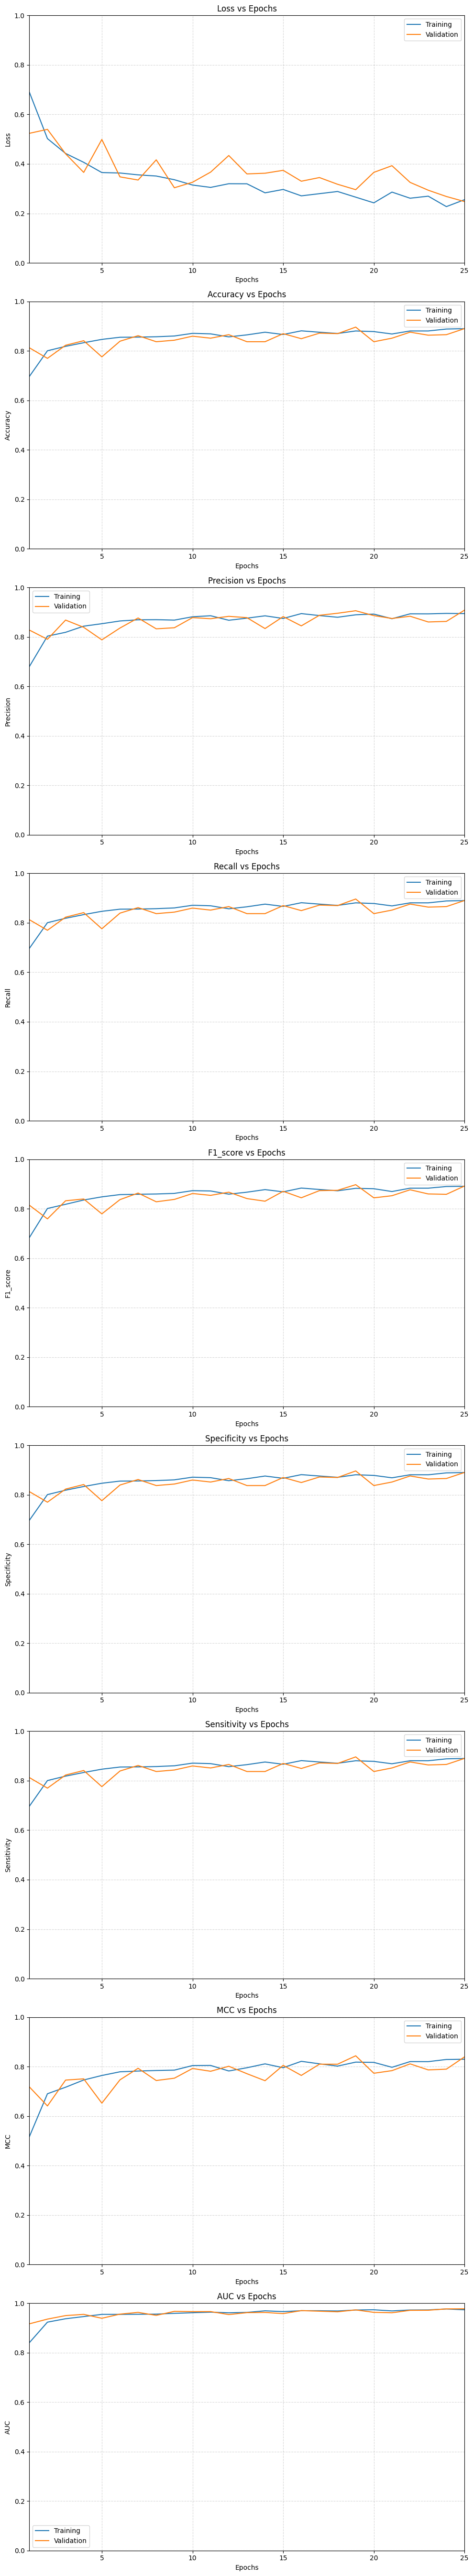

In [ ]:
def plot_metrics(train_metrics_history, val_metrics_history, metric_names):
    """
    Plots the given metrics for the training and validation sets.

    Args:
        train_metrics_history: a dictionary containing training metrics history
        val_metrics_history: a dictionary containing validation metrics history
        metric_names: a list of strings representing the names of the metrics to plot

    Returns:
        None
    """
    num_metrics = len(metric_names)
    num_epochs = len(train_metrics_history[metric_names[0]])

    figure, axes = plt.subplots(num_metrics, figsize=(10, 6 * num_metrics))

    rng = range(1, num_epochs + 1)

    for ax, metric_name in zip(axes, metric_names):
        train_metric = train_metrics_history[metric_name]
        val_metric = val_metrics_history[metric_name]

        ax.plot(rng, train_metric, label="Training")
        ax.plot(rng, val_metric, label="Validation")
        ax.legend()
        ax.set_xlabel("Epochs")

        if metric_name in ("auc", "mcc"):
            ax.set_ylabel(metric_name.upper())
            ax.set_title(metric_name.upper() + " vs Epochs")
        else:
            ax.set_ylabel(metric_name.capitalize())
            ax.set_title(metric_name.capitalize() + " vs Epochs")

        max_metric = max(max(train_metric), max(val_metric))
        min_metric = min(min(train_metric), min(val_metric))
        y_max = math.ceil(max_metric)

        if min_metric > 0 or max_metric > 1:
            ax.set_ylim(0, y_max)
        else:
            ax.set_ylim(min_metric, y_max)

        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_xlim(1, num_epochs)

    plt.tight_layout()
    plt.show()

plot_metrics(train_metrics_history, val_metrics_history, metric_names)

In [ ]:
# Define class names
class_names = ['meningioma', 'glioma', 'pituitary tumor']

@torch.no_grad()
def generate_classification_report(model, dataloader, target_names, device='cpu'):
    model.eval()
    model.to(device)

    predicted_labels = []
    true_labels = []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        if labels.ndim > 1:  # If one-hot encoded
            labels = torch.argmax(labels, dim=1)

        predicted_labels.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

    report = classification_report(
        true_labels,
        predicted_labels,
        target_names=target_names,
        digits=4,
        zero_division=1
    )

    accuracy = accuracy_score(true_labels, predicted_labels)
    num_errors = np.sum(np.array(true_labels) != np.array(predicted_labels))

    print(report)
    print(f'There were {num_errors} errors in {len(predicted_labels)} tests for an accuracy of {accuracy * 100:6.2f}%')

    return true_labels, predicted_labels

true_labels, predicted_labels = generate_classification_report(model, test_loader, target_names=class_names)

                 precision    recall  f1-score   support

     meningioma     0.7418    0.9507    0.8333       142
         glioma     0.9958    0.8316    0.9063       285
pituitary tumor     0.9534    0.9892    0.9710       186

       accuracy                         0.9070       613
      macro avg     0.8970    0.9238    0.9035       613
   weighted avg     0.9241    0.9070    0.9090       613

There were 57 errors in 613 tests for an accuracy of  90.70%


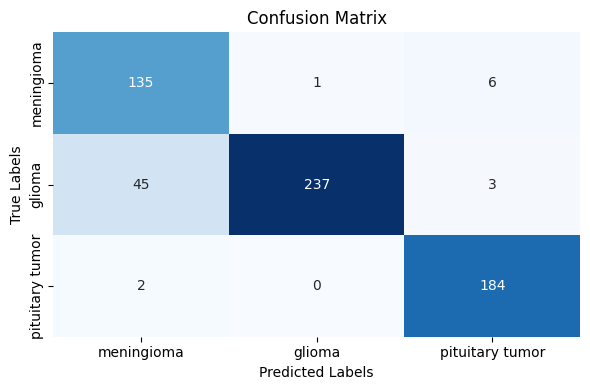

In [ ]:
def plot_confusion_matrix(true_labels, predicted_labels, class_names):
    cm = np.zeros((len(class_names), len(class_names)), dtype=int)
    np.add.at(cm, (true_labels, predicted_labels), 1)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(true_labels, predicted_labels, class_names)